# Calculating the correction to the sidereal dipole component

In [30]:
import numpy as np

Sidereal dipole:

Tier 1:
  Amplitude (2D): 0.00059 ± 0.00013
  Phase (2D):     237.759 ± 12.852
Tier 2:
  Amplitude (2D): 0.00232 ± 0.00015
  Phase (2D):     268.493 ± 3.756
Tier 3:
  Amplitude (2D): 0.00261 ± 0.00019
  Phase (2D):     278.920 ± 4.116
Tier 4:
  Amplitude (2D): 0.00178 ± 0.00054
  Phase (2D):     303.336 ± 17.523

In [31]:
sid_amp   = np.array([0.00059, 0.00232, 0.00261, 0.00178])
sid_phase = np.array([237.759, 268.493, 278.920, 303.336])
sid_phase *= np.pi/180.

Solar dipole:

Tier 1:
  Amplitude (2D): 0.00032 ± 0.00013
  Phase (2D):     96.928 ± 23.562
Tier 2:
  Amplitude (2D): 0.00041 ± 0.00015
  Phase (2D):     84.751 ± 21.437
Tier 3:
  Amplitude (2D): 0.00030 ± 0.00019
  Phase (2D):     58.863 ± 35.240
Tier 4:
  Amplitude (2D): 0.00032 ± 0.00053
  Phase (2D):     28.950 ± 95.642

In [32]:
sol_amp   = np.array([0.00032, 0.00041, 0.00030, 0.00032])
sol_phase = np.array([96.928, 84.751, 58.863, 28.950])
sol_phase *= np.pi/180.

Anti-sidereal dipole:

Tier 1:
  Amplitude (2D): 0.00017 ± 0.00013
  Phase (2D):     38.635 ± 44.912
Tier 2:
  Amplitude (2D): 0.00022 ± 0.00015
  Phase (2D):     260.168 ± 40.077
Tier 3:
  Amplitude (2D): 0.00011 ± 0.00019
  Phase (2D):     348.777 ± 94.284
Tier 4:
  Amplitude (2D): 0.00036 ± 0.00053
  Phase (2D):     124.511 ± 83.518

In [33]:
asid_amp   = np.array([0.00017, 0.00022, 0.00011, 0.00036])
asid_phase = np.array([38.635, 260.168, 348.777, 124.511])
asid_phase *= np.pi/180.

In [9]:
# sol_phase   = phi1
# asid_phase  = phi1 - phi2
# sid_phase   = phi1 + phi2

phi1       = sol_phase
phi2       = (phi1 - asid_phase)
dsid_phase = (phi1 + phi2)

# Amplitude/phase correction for negative signs
# for i in range(1, 4):
#     if dsid_phase[i] < 0:
#         dsid_phase[i] += 2*np.pi
#     dsid_phase[i] %= 2*np.pi

print(sid_phase)
print(dsid_phase)

[4.14967738 4.68608687 4.86807235 5.29421194]
[ 2.70911752 -1.58242022 -4.03260069 -1.16258127]


In [91]:
corr_sid_phase = sid_phase + dsid_phase

# Amplitude/phase correction for negative signs
for i in range(1, 4):
    if corr_sid_phase[i] < 0:
        corr_sid_phase[i] += 2*np.pi
    corr_sid_phase[i] %= 2*np.pi

print(corr_sid_phase)

[6.85879489 3.10366665 0.83547166 4.13163067]


In [109]:
print('Sidereal amplitude: ', sid_amp*1e3, '\nSidereal phase: ', sid_phase/np.pi*180., '\n')

alpha = 2.*sol_phase - asid_phase #dsid_phase - sid_phase
#print(alpha)

beta = np.arctan2( (sid_amp * np.cos(alpha)), (sid_amp + asid_amp * np.cos(alpha)) )
#print(beta/np.pi*180.)

corr_sid_amp   = (sid_amp + asid_amp * np.cos(alpha)) / np.cos(beta)
corr_sid_phase = (sid_phase+beta)
print(f'Corrected sidereal amplitude:', ['{:0.2f}'.format(x) for x in corr_sid_amp*1e3])
print(f'Corrected phase:', ['{:0.3f}'.format(x) for x in corr_sid_phase/np.pi*180.])

Sidereal amplitude:  [0.59 2.32 2.61 1.78] 
Sidereal phase:  [237.759 268.493 278.92  303.336] 

Corrected sidereal amplitude: ['0.44', '2.32', '2.54', '1.92']
Corrected phase: ['237.728', '268.491', '278.826', '303.376']


In [106]:
print(['{:0.2f}'.format(x) for x in (corr_sid_amp-sid_amp)*1e3])

['-0.15', '-0.00', '-0.07', '0.14']


In [110]:
print(['{:0.2f}'.format(x) for x in (corr_sid_phase-sid_phase)*180./np.pi])

['-0.03', '-0.00', '-0.09', '0.04']


In [7]:
# sol_phase   = phi1
# asid_phase  = phi1 - phi2
# corr_sid_phase   = phi1 + phi2

phi1           = sol_phase
phi2           = (phi1 - asid_phase)
corr_sid_phase = (phi1 + phi2) # = sol + sol - asid = 2sol - asid

print(sid_phase)
print(corr_sid_phase)

[4.14967738 4.68608687 4.86807235 5.29421194]
[ 2.70911752 -1.58242022 -4.03260069 -1.16258127]


In [24]:
print('Measured sidereal amplitude: ', sid_amp*1e3, '\nMeasured sidereal phase: ', sid_phase/np.pi*180., '\n')

alpha = corr_sid_phase - sid_phase  # corr_sid_phase ~ sid_phase
#print(alpha/np.pi*180.)

beta = np.arctan( (asid_amp * np.sin(alpha))/(sid_amp + asid_amp * np.cos(alpha)) )  # beta ~ 0
#print(beta/np.pi*180.)

#corr_sid_amp   = (asid_amp * np.sin(alpha)) / np.sin(beta)
corr_sid_amp   = (sid_amp + asid_amp * np.cos(alpha)) / np.cos(beta)
corr_sid_phase = (sid_phase+beta)
print(f'Corrected sidereal amplitude:', ['{:0.2f}'.format(x) for x in corr_sid_amp*1e3])
print(f'Corrected phase:', ['{:0.3f}'.format(x) for x in corr_sid_phase/np.pi*180.])

Measured sidereal amplitude:  [0.59 2.32 2.61 1.78] 
Measured sidereal phase:  [237.759 268.493 278.92  303.336] 

Corrected sidereal amplitude: ['0.76', '2.54', '2.72', '2.14']
Corrected phase: ['237.759', '268.493', '278.920', '303.336']


In [22]:
print(['{:0.2f}'.format(x) for x in (corr_sid_amp-sid_amp)*1e3])

['0.17', '0.22', '0.11', '0.36']


In [23]:
print(['{:0.2f}'.format(x) for x in (corr_sid_phase-sid_phase)*180./np.pi])

['0.00', '0.00', '0.00', '0.00']


In [25]:
# sol_phase   = phi1
# asid_phase  = phi1 - phi2
# corr_sid_phase   = phi1 + phi2

phi1           = sol_phase
phi2           = (phi1 - asid_phase)
corr_sid_phase = (phi1 + phi2) # = sol + sol - asid = 2sol - asid

print(sid_phase)
print(corr_sid_phase)

[4.14967738 4.68608687 4.86807235 5.29421194]
[ 2.70911752 -1.58242022 -4.03260069 -1.16258127]


In [26]:
print('Measured sidereal amplitude: ', sid_amp*1e3, '\nMeasured sidereal phase: ', sid_phase/np.pi*180., '\n')

alpha = corr_sid_phase - sid_phase  # corr_sid_phase ~ sid_phase
#print(alpha/np.pi*180.)

cos_beta = np.sqrt( 1 - (asid_amp*np.sin(alpha)/sid_amp)**2 )
beta     = np.arccos(cos_beta)
#print(beta/np.pi*180.)

corr_sid_amp = sid_amp*cos_beta - asid_amp*np.cos(alpha)
corr_sid_phase = (sid_phase - beta)
print(f'Corrected sidereal amplitude:', ['{:0.2f}'.format(x) for x in corr_sid_amp*1e3])
print(f'Corrected phase:', ['{:0.3f}'.format(x) for x in corr_sid_phase/np.pi*180.])

Measured sidereal amplitude:  [0.59 2.32 2.61 1.78] 
Measured sidereal phase:  [237.759 268.493 278.92  303.336] 

Corrected sidereal amplitude: ['0.54', '2.10', '2.70', '1.42']
Corrected phase: ['221.159', '268.413', '277.711', '301.334']


In [27]:
print(['{:0.2f}'.format(x) for x in (corr_sid_amp-sid_amp)*1e3])

['-0.05', '-0.22', '0.09', '-0.36']


In [28]:
print(['{:0.2f}'.format(x) for x in (corr_sid_phase-sid_phase)*180./np.pi])

['-16.60', '-0.08', '-1.21', '-2.00']


# Fit Data Maps

In [29]:
from glob import glob

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from Fit2d import multipoleFit2d, returnRI, multipoleFit1D

## Load Sidereal Sky Maps

In [30]:
# Load in maps

relint_files = {}
relerr_files = {}
root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/sidereal_unblinded'
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/antisidereal_unblinded'
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/solar_unblinded'

tiers = [i for i in range(1, 5)]
#ntiers = [i for i in range(1, 6)]

for tier in tiers:
    files = glob(f'{root}/tier{tier}/reconstruction/relintensityiter/combined*.fits.gz')
    relint_files[tier] = sorted(files)[-1]

    files = glob(f'{root}/tier{tier}/reconstruction/significanceiter/significance*.fits.gz')
    relerr_files[tier] = sorted(files)[-1]

# No Cut
# files = glob(f'{root}/nocuts/reconstruction/relintensityiter/combined*.fits.gz')
# relint_files[5] = sorted(files)[-1]

# files = glob(f'{root}/nocuts/reconstruction/significanceiter/significance*.fits.gz')
# relerr_files[5] = sorted(files)[-1]


print('Relative intensity files:')
for tier, map_file in relint_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

print('Relative error files:')
for tier, map_file in relerr_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

Relative intensity files:
  Tier 1 : {root}/tier1/reconstruction/relintensityiter/combined_t1_iteration04.fits.gz
  Tier 2 : {root}/tier2/reconstruction/relintensityiter/combined_t2_iteration20.fits.gz
  Tier 3 : {root}/tier3/reconstruction/relintensityiter/combined_t3_iteration20.fits.gz
  Tier 4 : {root}/tier4/reconstruction/relintensityiter/combined_t4_iteration20.fits.gz
Relative error files:
  Tier 1 : {root}/tier1/reconstruction/significanceiter/significance_t1_iteration04.fits.gz
  Tier 2 : {root}/tier2/reconstruction/significanceiter/significance_t2_iteration20.fits.gz
  Tier 3 : {root}/tier3/reconstruction/significanceiter/significance_t3_iteration20.fits.gz
  Tier 4 : {root}/tier4/reconstruction/significanceiter/significance_t4_iteration20.fits.gz


### Computing Dipole Phase and Amplitude

In [31]:
nfiles = len(relint_files.keys())
l = 3   # Taken from plotMaker.py which shows the arguments used
decmin = -90.
decmax = -35.

amp, phase, amp_err, phase_err = np.zeros((4, nfiles))
amp_1d, phase_1d, amp_err_1d, phase_err_1d = np.zeros((4, nfiles))


chi2sums  = np.zeros(nfiles)
pvals = np.zeros(nfiles)
ndofs = np.zeros(nfiles)

In [32]:
# Calculate 2D fit with standard masking
for i, tier in enumerate(tiers):

    data, bg, relint = hp.read_map(relint_files[tier], range(3))
    relerr,_,_ = hp.read_map(relerr_files[tier], range(3))
    
    popt, perr, chi2, ndof, pvalue = multipoleFit2d(relint, relerr, l, decmax=decmax)

    a = np.reshape(popt, (-1,2))
    amp[i], phase[i] = a[0]
    
    
    # Amplitude/phase correction for negative signs
    if amp[i] < 0:
        amp[i] *= -1
        phase[i] += np.pi
    if phase[i] < 0:
        phase[i] += 2*np.pi
    phase[i] %= 2*np.pi

    e = np.reshape(perr, (-1,2))
    amp_err[i], phase_err[i] = e[0]
    chi2sums[i] = chi2
    ndofs[i] = ndof
    pvals[i] = pvalue

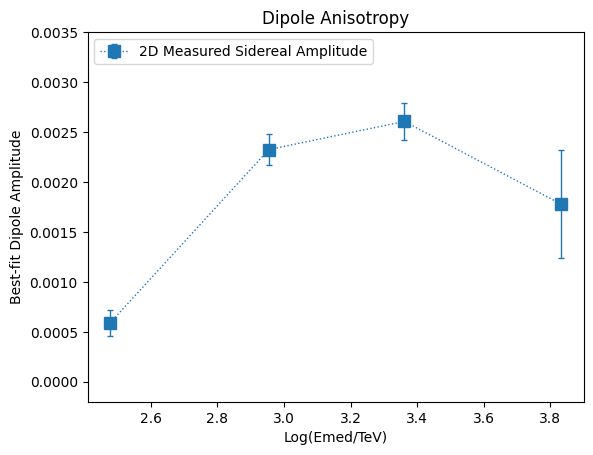

In [33]:
emed = np.array([np.log10(300), np.log10(900), np.log10(2300), np.log10(6800)], dtype=float)  # TeV

amp_sidereal       = amp
amp_err_sidereal   = amp_err
phase_sidereal     = phase
phase_err_sidereal = phase_err

fig, ax = plt.subplots()
#common_opts = {'marker':'.', 'markersize':8, 'ls':'-'}
#common_opts = {fmt='s:', markersize=8, linewidth=1, capsize=2, elinewidth=1}
common_opts = {'fmt': 's:', 'markersize': 8, 'linewidth': 1, 'capsize': 2, 'elinewidth': 1}
ax.errorbar(emed, amp_sidereal, yerr=amp_err_sidereal, label='2D Measured Sidereal Amplitude', **common_opts)
ax.legend(loc='upper left')
ax.set_title('Dipole Anisotropy')
ax.set_xlabel('Log(Emed/TeV)')
ax.set_ylabel('Best-fit Dipole Amplitude')
ax.set_ylim([-0.0002, 0.0035])
plt.show()

## Load Anti-Sidereal Sky Maps

In [34]:
# Load in maps

relint_files = {}
relerr_files = {}
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/sidereal_unblinded'
root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/antisidereal_unblinded'
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/solar_unblinded'

tiers = [i for i in range(1, 5)]
#ntiers = [i for i in range(1, 6)]

for tier in tiers:
    files = glob(f'{root}/tier{tier}/reconstruction/relintensityiter/combined*.fits.gz')
    relint_files[tier] = sorted(files)[-1]

    files = glob(f'{root}/tier{tier}/reconstruction/significanceiter/significance*.fits.gz')
    relerr_files[tier] = sorted(files)[-1]

# No Cut
# files = glob(f'{root}/nocuts/reconstruction/relintensityiter/combined*.fits.gz')
# relint_files[5] = sorted(files)[-1]

# files = glob(f'{root}/nocuts/reconstruction/significanceiter/significance*.fits.gz')
# relerr_files[5] = sorted(files)[-1]


print('Relative intensity files:')
for tier, map_file in relint_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

print('Relative error files:')
for tier, map_file in relerr_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

Relative intensity files:
  Tier 1 : {root}/tier1/reconstruction/relintensityiter/combined_t1_iteration20.fits.gz
  Tier 2 : {root}/tier2/reconstruction/relintensityiter/combined_t2_iteration03.fits.gz
  Tier 3 : {root}/tier3/reconstruction/relintensityiter/combined_t3_iteration20.fits.gz
  Tier 4 : {root}/tier4/reconstruction/relintensityiter/combined_t4_iteration20.fits.gz
Relative error files:
  Tier 1 : {root}/tier1/reconstruction/significanceiter/significance_t1_iteration20.fits.gz
  Tier 2 : {root}/tier2/reconstruction/significanceiter/significance_t2_iteration03.fits.gz
  Tier 3 : {root}/tier3/reconstruction/significanceiter/significance_t3_iteration20.fits.gz
  Tier 4 : {root}/tier4/reconstruction/significanceiter/significance_t4_iteration20.fits.gz


### Computing Dipole Phase and Amplitude

In [35]:
nfiles = len(relint_files.keys())
l = 3   # Taken from plotMaker.py which shows the arguments used
decmin = -90.
decmax = -35.

amp, phase, amp_err, phase_err = np.zeros((4, nfiles))
amp_1d, phase_1d, amp_err_1d, phase_err_1d = np.zeros((4, nfiles))


chi2sums  = np.zeros(nfiles)
pvals = np.zeros(nfiles)
ndofs = np.zeros(nfiles)

In [36]:
# Calculate 2D fit with standard masking
for i, tier in enumerate(tiers):

    data, bg, relint = hp.read_map(relint_files[tier], range(3))
    relerr,_,_ = hp.read_map(relerr_files[tier], range(3))
    
    popt, perr, chi2, ndof, pvalue = multipoleFit2d(relint, relerr, l, decmax=decmax)

    a = np.reshape(popt, (-1,2))
    amp[i], phase[i] = a[0]
    
    
    # Amplitude/phase correction for negative signs
    if amp[i] < 0:
        amp[i] *= -1
        phase[i] += np.pi
    if phase[i] < 0:
        phase[i] += 2*np.pi
    phase[i] %= 2*np.pi

    e = np.reshape(perr, (-1,2))
    amp_err[i], phase_err[i] = e[0]
    chi2sums[i] = chi2
    ndofs[i] = ndof
    pvals[i] = pvalue

Anti-Sidereal Amplitude [0.16865748 0.2180179  0.11389732 0.36235564] [0.13212128 0.15253995 0.1871974  0.52822512]
Anti-Sidereal Phase [ 38.63465921 260.16820773 348.77677476 124.51117355] [44.91156274 40.07672237 94.28448832 83.5178868 ]


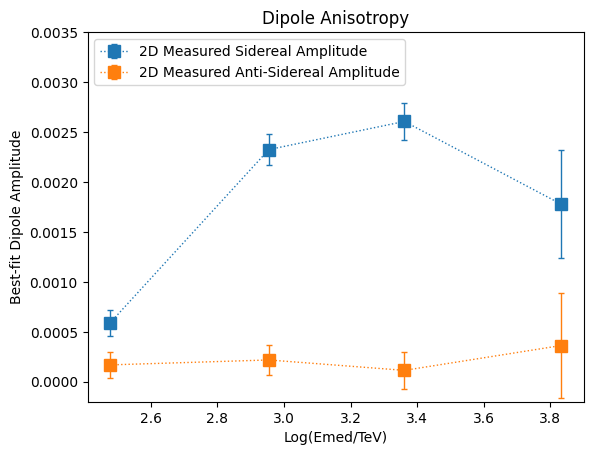

In [37]:
emed = np.array([np.log10(300), np.log10(900), np.log10(2300), np.log10(6800)], dtype=float)  # TeV

amp_antisidereal       = amp
amp_err_antisidereal   = amp_err
phase_antisidereal     = phase
phase_err_antisidereal = phase_err

print("Anti-Sidereal Amplitude", amp_antisidereal*1e3, amp_err_antisidereal*1e3)
print("Anti-Sidereal Phase", phase_antisidereal*180/np.pi, phase_err_antisidereal*180/np.pi)

fig, ax = plt.subplots()
#common_opts = {'marker':'.', 'markersize':8, 'ls':'-'}
common_opts = {'fmt': 's:', 'markersize': 8, 'linewidth': 1, 'capsize': 2, 'elinewidth': 1}
ax.errorbar(emed, amp_sidereal, yerr=amp_err_sidereal, label='2D Measured Sidereal Amplitude', **common_opts)
ax.errorbar(emed, amp_antisidereal, yerr=amp_err_antisidereal, label='2D Measured Anti-Sidereal Amplitude', **common_opts)
ax.legend(loc='upper left')
ax.set_title('Dipole Anisotropy')
ax.set_xlabel('Log(Emed/TeV)')
ax.set_ylabel('Best-fit Dipole Amplitude')
ax.set_ylim([-0.0002, 0.0035])
plt.show()

## Load Solar Sky Maps

In [38]:
# Load in maps

relint_files = {}
relerr_files = {}
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/sidereal_unblinded'
#root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/antisidereal_unblinded'
root = '/data/ana/CosmicRay/Anisotropy/IceTop/ITpass2/output/solar_unblinded'

tiers = [i for i in range(1, 5)]
#ntiers = [i for i in range(1, 6)]

for tier in tiers:
    files = glob(f'{root}/tier{tier}/reconstruction/relintensityiter/combined*.fits.gz')
    relint_files[tier] = sorted(files)[-1]

    files = glob(f'{root}/tier{tier}/reconstruction/significanceiter/significance*.fits.gz')
    relerr_files[tier] = sorted(files)[-1]

# No Cut
# files = glob(f'{root}/nocuts/reconstruction/relintensityiter/combined*.fits.gz')
# relint_files[5] = sorted(files)[-1]

# files = glob(f'{root}/nocuts/reconstruction/significanceiter/significance*.fits.gz')
# relerr_files[5] = sorted(files)[-1]


print('Relative intensity files:')
for tier, map_file in relint_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

print('Relative error files:')
for tier, map_file in relerr_files.items():
    print(f'  Tier {tier} : {{root}}{map_file.replace(root,"")}')

Relative intensity files:
  Tier 1 : {root}/tier1/reconstruction/relintensityiter/combined_t1_iteration20.fits.gz
  Tier 2 : {root}/tier2/reconstruction/relintensityiter/combined_t2_iteration20.fits.gz
  Tier 3 : {root}/tier3/reconstruction/relintensityiter/combined_t3_iteration08.fits.gz
  Tier 4 : {root}/tier4/reconstruction/relintensityiter/combined_t4_iteration20.fits.gz
Relative error files:
  Tier 1 : {root}/tier1/reconstruction/significanceiter/significance_t1_iteration20.fits.gz
  Tier 2 : {root}/tier2/reconstruction/significanceiter/significance_t2_iteration20.fits.gz
  Tier 3 : {root}/tier3/reconstruction/significanceiter/significance_t3_iteration08.fits.gz
  Tier 4 : {root}/tier4/reconstruction/significanceiter/significance_t4_iteration20.fits.gz


### Computing Dipole Phase and Amplitude

In [39]:
nfiles = len(relint_files.keys())
l = 3   # Taken from plotMaker.py which shows the arguments used
decmin = -90.
decmax = -35.

amp, phase, amp_err, phase_err = np.zeros((4, nfiles))
amp_1d, phase_1d, amp_err_1d, phase_err_1d = np.zeros((4, nfiles))


chi2sums  = np.zeros(nfiles)
pvals = np.zeros(nfiles)
ndofs = np.zeros(nfiles)

In [40]:
# Calculate 2D fit with standard masking
for i, tier in enumerate(tiers):

    data, bg, relint = hp.read_map(relint_files[tier], range(3))
    relerr,_,_ = hp.read_map(relerr_files[tier], range(3))
    
    popt, perr, chi2, ndof, pvalue = multipoleFit2d(relint, relerr, l, decmax=decmax)

    a = np.reshape(popt, (-1,2))
    amp[i], phase[i] = a[0]
    
    
    # Amplitude/phase correction for negative signs
    if amp[i] < 0:
        amp[i] *= -1
        phase[i] += np.pi
    if phase[i] < 0:
        phase[i] += 2*np.pi
    phase[i] %= 2*np.pi

    e = np.reshape(perr, (-1,2))
    amp_err[i], phase_err[i] = e[0]
    chi2sums[i] = chi2
    ndofs[i] = ndof
    pvals[i] = pvalue

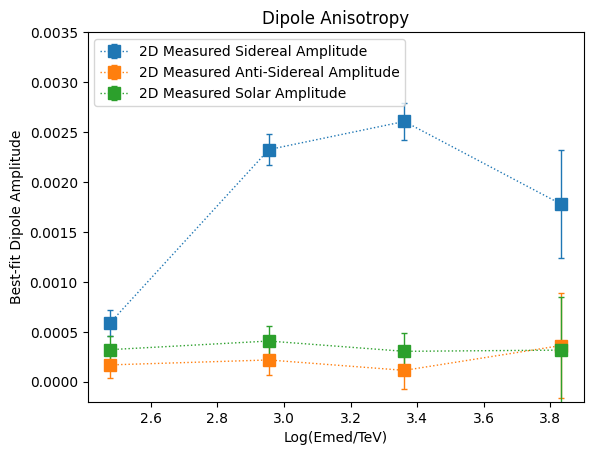

In [41]:
emed = np.array([np.log10(300), np.log10(900), np.log10(2300), np.log10(6800)], dtype=float)  # TeV

amp_solar       = amp
amp_err_solar   = amp_err
phase_solar     = phase
phase_err_solar = phase_err

fig, ax = plt.subplots()
#common_opts = {'marker':'.', 'markersize':8, 'ls':'-'}
common_opts = {'fmt': 's:', 'markersize': 8, 'linewidth': 1, 'capsize': 2, 'elinewidth': 1}
ax.errorbar(emed, amp_sidereal, yerr=amp_err_sidereal, label='2D Measured Sidereal Amplitude', **common_opts)
ax.errorbar(emed, amp_antisidereal, yerr=amp_err_antisidereal, label='2D Measured Anti-Sidereal Amplitude', **common_opts)
ax.errorbar(emed, amp_solar, yerr=amp_err_solar, label='2D Measured Solar Amplitude', **common_opts)
ax.legend(loc='upper left')
ax.set_title('Dipole Anisotropy')
ax.set_xlabel('Log(Emed/TeV)')
ax.set_ylabel('Best-fit Dipole Amplitude')
ax.set_ylim([-0.0002, 0.0035])
plt.show()

In [43]:
print('Sidereal Dipole Component:')
print(['{:0.3f}'.format(x) for x in (amp_sidereal)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_sidereal)*180./np.pi])

print('\nAnti-Sidereal Dipole Component')
print(['{:0.3f}'.format(x) for x in (amp_antisidereal)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_antisidereal)*180./np.pi])

print('\nAnti-Sidereal Errors on the Dipole Component')
print(['{:0.3f}'.format(x) for x in (amp_err_antisidereal)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_err_antisidereal)*180./np.pi])

print('\nSolar Dipole Component')
print(['{:0.3f}'.format(x) for x in (amp_solar)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_solar)*180./np.pi])

print('\nSolar Errors on the Dipole Component')
print(['{:0.3f}'.format(x) for x in (amp_err_solar)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_err_solar)*180./np.pi])

Sidereal Dipole Component:
['0.589', '2.324', '2.606', '1.779']
['237.759', '268.493', '278.920', '303.336']

Anti-Sidereal Dipole Component
['0.169', '0.218', '0.114', '0.362']
['38.635', '260.168', '348.777', '124.511']

Anti-Sidereal Errors on the Dipole Component
['0.132', '0.153', '0.187', '0.528']
['44.912', '40.077', '94.284', '83.518']

Solar Dipole Component
['0.321', '0.408', '0.305', '0.317']
['96.928', '84.751', '58.863', '28.950']

Solar Errors on the Dipole Component
['0.132', '0.152', '0.187', '0.529']
['23.562', '21.437', '35.240', '95.642']


# Final Systematic Calculation

## Vector calculation of systematic interference on the sidereal dipole (Farley & Storey)

In [16]:
# Measured Sidereal Dipole
vector_measured_sid      = np.array( [amp_sidereal * np.cos(phase_sidereal), amp_sidereal * np.sin(phase_sidereal)] )
#print(vector_measured_sid[0][0])

phi1 = phase_solar
phi2 = phase_solar - phase_antisidereal

# Correction to the Sidereal Dipole
vector_measured_corr_sid = np.array( [amp_antisidereal * np.cos(phi1 + phi2), amp_antisidereal * np.sin(phi1 + phi2)] )
# True Sidereal Dipole
vector_true_sid          = vector_measured_sid - vector_measured_corr_sid

# Measured Sidereal Dipole's Amplitude and Phase
amp_m_sid   = np.sqrt(vector_measured_sid[0]**2 + vector_measured_sid[1]**2)
phase_m_sid = np.arctan2(vector_measured_sid[1], vector_measured_sid[0])
print(amp_m_sid*1e3, phase_m_sid/np.pi*180.+360.)

# True Sidereal Dipole's Amplitude and Phase
amp_t_sid   = np.sqrt(vector_true_sid[0]**2 + vector_true_sid[1]**2)
phase_t_sid = np.arctan2(vector_true_sid[1], vector_true_sid[0])
print(amp_t_sid*1e3, phase_t_sid/np.pi*180.+360.)

[0.58909567 2.32400938 2.60574241 1.77863767] [237.75858469 268.49305282 278.92025521 303.33574557]
[0.59132882 2.1060174  2.70495296 1.42310571] [254.18607785 268.40598903 280.12764617 305.85651328]


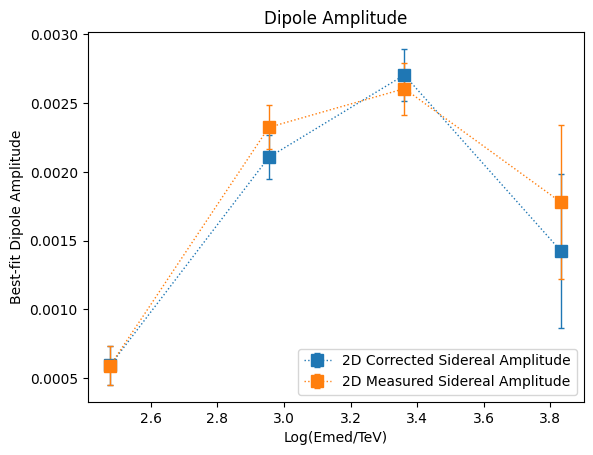

In [17]:
import matplotlib.pyplot as plt

emed = np.array([np.log10(300), np.log10(900), np.log10(2300), np.log10(6800)], dtype=float)  # TeV

amp_sid_error     = np.array([0.00014, 0.00016, 0.00019, 0.00056])

fig, ax = plt.subplots()
#common_opts = {'marker':'.', 'markersize':8, 'ls':'-'}
common_opts = {'fmt': 's:', 'markersize': 8, 'linewidth': 1, 'capsize': 2, 'elinewidth': 1}
ax.errorbar(emed, amp_t_sid, yerr=amp_sid_error, label='2D Corrected Sidereal Amplitude', **common_opts)
ax.errorbar(emed, amp_m_sid, yerr=amp_sid_error, label='2D Measured Sidereal Amplitude', **common_opts)
ax.legend(loc='lower right')
ax.set_xlabel('Log(Emed/TeV)')
ax.set_ylabel('Best-fit Dipole Amplitude')
ax.set_title('Dipole Amplitude')
plt.show()

In [18]:
# print('Sidereal Dipole Component:')
# print(['{:0.3f}'.format(x) for x in (amp_sidereal)*1e3])
# print(['{:0.3f}'.format(x) for x in (phase_sidereal)*180./np.pi])

print('Measured Sidereal Dipole Component:')
print(['{:0.3f}'.format(x) for x in (amp_m_sid)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_m_sid)*180./np.pi+360])

print('True Sidereal Dipole Component:')
print(['{:0.3f}'.format(x) for x in (amp_t_sid)*1e3])
print(['{:0.3f}'.format(x) for x in (phase_t_sid)*180./np.pi+360])

Measured Sidereal Dipole Component:
['0.589', '2.324', '2.606', '1.779']
['237.759', '268.493', '278.920', '303.336']
True Sidereal Dipole Component:
['0.591', '2.106', '2.705', '1.423']
['254.186', '268.406', '280.128', '305.857']


Tier 1:
  Amplitude (2D): 0.00059 ± 0.00013
  Phase (2D):     4.150 ± 0.224
Tier 2:
  Amplitude (2D): 0.00232 ± 0.00015
  Phase (2D):     4.686 ± 0.066
Tier 3:
  Amplitude (2D): 0.00261 ± 0.00019
  Phase (2D):     4.868 ± 0.072
Tier 4:
  Amplitude (2D): 0.00178 ± 0.00054
  Phase (2D):     5.294 ± 0.306

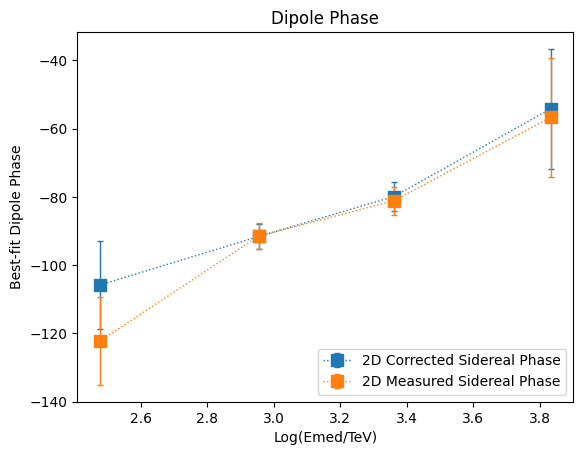

In [19]:
#phase_sid_error     = np.array([0.224, 0.066, 0.072, 0.306])
# Use phase_err_sidereal

fig, ax = plt.subplots()
#common_opts = {'marker':'.', 'markersize':8, 'ls':'-'}
common_opts = {'fmt': 's:', 'markersize': 8, 'linewidth': 1, 'capsize': 2, 'elinewidth': 1}
ax.errorbar(emed, phase_t_sid*180./np.pi, yerr=phase_err_sidereal*180./np.pi, label='2D Corrected Sidereal Phase', **common_opts)
ax.errorbar(emed, phase_m_sid*180./np.pi, yerr=phase_err_sidereal*180./np.pi, label='2D Measured Sidereal Phase', **common_opts)
ax.legend(loc='lower right')
ax.set_xlabel('Log(Emed/TeV)')
ax.set_ylabel('Best-fit Dipole Phase')
ax.set_title('Dipole Phase')
plt.show()

In [20]:
print(['{:0.2f}'.format(x) for x in (amp_t_sid-amp_m_sid)*1e3])
print(['{:0.2f}'.format(x) for x in (phase_t_sid-phase_m_sid)*180./np.pi])

['0.00', '-0.22', '0.10', '-0.36']
['16.43', '-0.09', '1.21', '2.52']
